# Week 2: Hands on

Use again our [penicillin data set](https://dls.hevs.ch/ts/files/penicillin-data-01.csv).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('https://dls.hevs.ch/ts/files/penicillin-data-01.csv')

1. What is the batch with maximal average temperature?

In [2]:
T_avg = np.array([df[df['Batch ID'] == i]['Temperature(T:K)'].mean() for i in range(1,101)]) # Build the array of average value of each batch.
T_avg_max = T_avg.max() # Max avg temp
idx_max = np.argmax(T_avg) # Index of max avg temp

print(f'Max average temperature: {T_avg_max}')
print(f'Batch with largest average temperature: #{idx_max+1}')

Max average temperature: 298.2783714285714
Batch with largest average temperature: #93


2. Is this batch’s temperature time series really exceptional compared to the others? Justify.
    
    1. Find the batch whose average temperature is the most “central” one.
  
    2. Compare the distribution of temperature between theses two batches (e.g., with a histogram or a box plot).
  
    3. What can you see?

In [3]:
T_avg_med = np.median(T_avg)

# The batch with the most central average temperature is the one whose T_avg has the lowest difference with T_avg_med.
idx_med = np.argmin(np.abs(T_avg - T_avg_med))
print(f'Most central batch: #{idx_med+1}')

Most central batch: #33


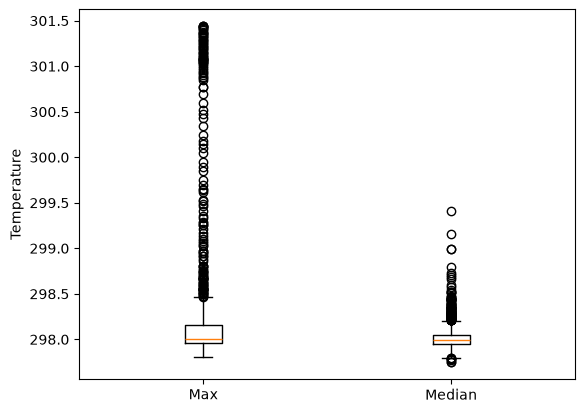

In [4]:
fig, ax = plt.subplots()

ax.boxplot([df[df['Batch ID'] == 93]['Temperature(T:K)'], df[df['Batch ID'] == 33]['Temperature(T:K)']])
ax.set_xticks([1,2], ['Max','Median'])
ax.set_ylabel('Temperature')

plt.show()

Whereas in general, temperatures in batch 93 seem to be larger that in batch 33, the difference in average temparature is most likely due to a very large number of outlier values.
The bulk of the temperatures remain very close to a fixed value.

3. Do the same with the batch with lowest average temperature. What changes?

Min average temperature: 297.99155652173914
Batch with smallest average temperature: #86


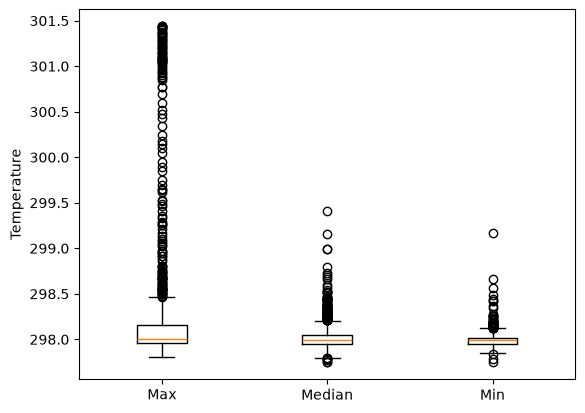

In [5]:
T_avg_min = T_avg.min() # Min avg temp
idx_min = np.argmin(T_avg) # Index of min avg temp

print(f'Min average temperature: {T_avg_min}')
print(f'Batch with smallest average temperature: #{idx_min+1}')

fig, ax = plt.subplots()

ax.boxplot([df[df['Batch ID'] == 93]['Temperature(T:K)'], df[df['Batch ID'] == 33]['Temperature(T:K)'], df[df['Batch ID'] == (idx_min+1)]['Temperature(T:K)']])
ax.set_xticks([1,2,3], ['Max','Median','Min'])
ax.set_ylabel('Temperature')

plt.show()


There is no outliers to the bottom. 
The smallest average temperature is very close to the median average temperature.

4. In theses samples, is there a correlation between concentration and pH? Between concentration and temperature? Between pH and temperature?

                                 Time (h)  Batch ID  \
Time (h)                         1.000000 -0.010151   
Batch ID                        -0.010151  1.000000   
Penicillin concentration(P:g/L)  0.870176 -0.042901   
pH(pH:pH)                        0.046578 -0.029155   
Temperature(T:K)                -0.256685  0.057682   

                                 Penicillin concentration(P:g/L)  pH(pH:pH)  \
Time (h)                                                0.870176   0.046578   
Batch ID                                               -0.042901  -0.029155   
Penicillin concentration(P:g/L)                         1.000000   0.003703   
pH(pH:pH)                                               0.003703   1.000000   
Temperature(T:K)                                       -0.279469  -0.010693   

                                 Temperature(T:K)  
Time (h)                                -0.256685  
Batch ID                                 0.057682  
Penicillin concentration(P:g/L)       

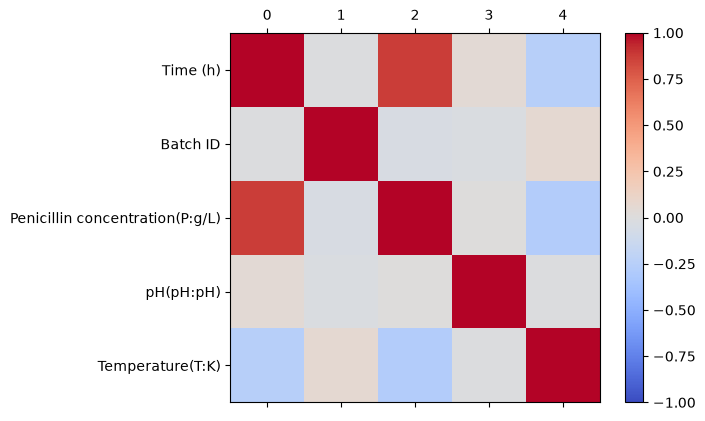

In [6]:
r = df.corr()
print(r)

fig, ax = plt.subplots()
rax = ax.matshow(r, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(rax)

ax.set_yticks(range(len(r.columns)))
ax.set_yticklabels(r.columns)

plt.show()

The concentration of penicillin is strongly correlated with time, meaning that the concentration increases as time increases. 

5. Is it expected?

Yes, the purpose of the bioreactor is to produce penicillin, therefore we expect the amount of penicillin to increase over time.

6. (Optional) Among the other quantities in the original data set is there one where you expect to see a correlation with the penicillin concentration? Justify.

7. (Optional) Test your prediction by importing the data and computing the correlation.